Integrating Proton...
Integrating Alpha Particle...
Integrating Electron...


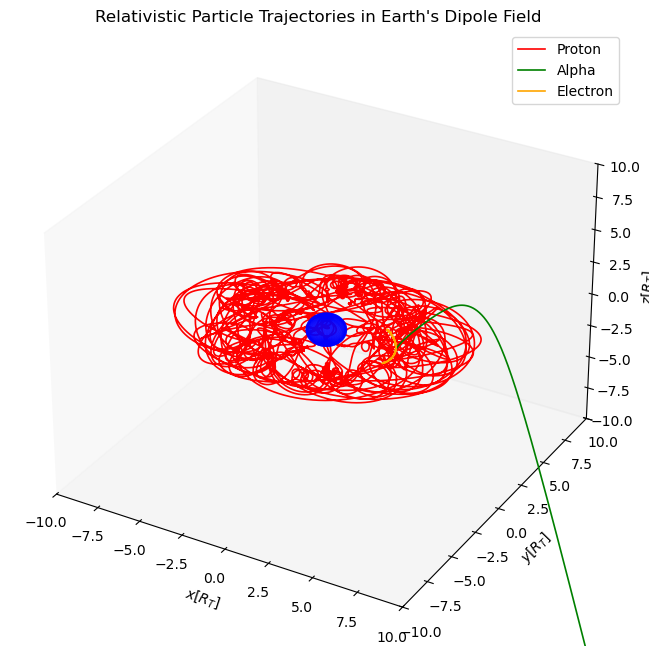

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class PlasmaSimulator:
    def __init__(self):
        # Physical Constants
        self.c = 299792458.0        # Speed of light [m/s]
        self.RZ = 6378137.0         # Earth radius [m]
        self.qe = 1.6021766210e-19  # Elementary charge [C]
        self.m_e = 9.10938356e-31   # Electron mass [kg]
        self.m_p = 1.6726219e-27    # Proton mass [kg]
        self.m_alpha = 4.001506179127 * 1.66053906660e-27 # Alpha particle mass [kg]
        
        # Magnetic Axis Tilt (11.7 degrees)
        angle_rad = 11.7 * np.pi / 180.0
        self.sinphi = np.sin(angle_rad)
        self.cosphi = np.cos(angle_rad)

    def get_particle_properties(self, p_type):
        """Returns charge and mass for a given particle type."""
        if p_type.lower() == 'electron':
            return -self.qe, self.m_e
        elif p_type.lower() == 'proton':
            return self.qe, self.m_p
        elif p_type.lower() == 'alpha':
            return 2.0 * self.qe, self.m_alpha
        else:
            raise ValueError("Unsupported particle type. Choose 'electron', 'proton', or 'alpha'.")

    def b_field_dipole(self, r):
        """
        Earth's dipole magnetic field analytical approximation.
        r: numpy array of shape (3,) representing position vector [x, y, z].
        Returns B: numpy array of shape (3,) representing magnetic field vector.
        """
        R_sq = r[0]**2 + r[1]**2 + r[2]**2
        pom = R_sq**2.5
        
        # Avoid division by zero at the exact center
        if pom == 0:
            return np.array([0.0, 0.0, 0.0])

        BPx = -7.965626e15 * ((3.0 * r[0] * r[2] * self.cosphi) + (3.0 * r[0] * r[1] * self.sinphi)) / pom
        BPy = -7.965626e15 * ((3.0 * r[1] * r[2] * self.cosphi) + (2.0 * self.sinphi * (r[1]**2)) - (self.sinphi * (r[0]**2)) - (self.sinphi * (r[2]**2))) / pom
        BPz = -7.965626e15 * ((2.0 * self.cosphi * (r[2]**2)) - (self.cosphi * (r[0]**2)) - (self.cosphi * (r[1]**2)) + (3.0 * r[2] * r[1] * self.sinphi)) / pom
        
        return np.array([BPx, BPy, BPz])

    def integrate_boris_c(self, p_type, r0, v0, dt, t_sim):
        """
        Integrates the relativistic equation of motion using the Boris-C algorithm.
        """
        q, m = self.get_particle_properties(p_type)
        
        N_steps = int(t_sim / dt)
        
        # Initialize history arrays
        r_history = np.zeros((N_steps, 3))
        v_history = np.zeros((N_steps, 3))
        t_history = np.zeros(N_steps)
        
        # Initial Conditions
        r = np.array(r0, dtype=float)
        v = np.array(v0, dtype=float)
        
        # Convert initial v to relativistic u (u = gamma * v)
        gamma = 1.0 / np.sqrt(1.0 - (np.linalg.norm(v) / self.c)**2)
        u = gamma * v
        
        r_history[0] = r
        v_history[0] = v
        
        for i in range(1, N_steps):
            B = self.b_field_dipole(r)
            
            # Since E = 0, u_minus is just current u
            u_minus = u
            
            # Step 1: Calculate gamma
            gamma_n = np.sqrt(1.0 + (np.linalg.norm(u_minus) / self.c)**2)
            
            # Step 2: Calculate rotation vectors t and s
            t_vec = (q * dt / (2.0 * m * gamma_n)) * B
            t_mag_sq = np.dot(t_vec, t_vec)
            s_vec = (2.0 * t_vec) / (1.0 + t_mag_sq)
            
            # Step 3: Perform magnetic rotation
            u_prime = u_minus + np.cross(u_minus, t_vec)
            u_plus = u_minus + np.cross(u_prime, s_vec)
            
            # Since E = 0, u_next is just u_plus
            u = u_plus
            
            # Step 4: Update velocity and position
            gamma_next = np.sqrt(1.0 + (np.linalg.norm(u) / self.c)**2)
            v = u / gamma_next
            r = r + v * dt
            
            # Record data
            r_history[i] = r
            v_history[i] = v
            t_history[i] = i * dt
            
        return t_history, r_history, v_history

    def plot_3d_trajectory(self, histories, labels):
        """
        Visualizes the computed trajectories around Earth in 3D.
        histories: list of r_history arrays.
        labels: list of strings for legends.
        """
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.set_aspect('auto')
        ax.grid(False)
        
        # Draw Earth sphere
        u_sphere, v_sphere = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]
        x = np.cos(u_sphere) * np.sin(v_sphere)
        y = np.sin(u_sphere) * np.sin(v_sphere)
        z = np.cos(v_sphere)
        ax.plot_wireframe(x, y, z, color="blue", alpha=0.3)
        
        # Plot Trajectories
        colors = ['red', 'green', 'orange']
        for r_hist, label, color in zip(histories, labels, colors):
            ax.plot(r_hist[:, 0]/self.RZ, r_hist[:, 1]/self.RZ, r_hist[:, 2]/self.RZ, 
                    label=label, color=color, linewidth=1.2)
            
        ax.set_xlabel("$x [R_T]$")
        ax.set_ylabel("$y [R_T]$")
        ax.set_zlabel("$z [R_T]$")
        ax.set_xlim3d(-10, 10)
        ax.set_ylim3d(-10, 10)
        ax.set_zlim3d(-10, 10)
        plt.legend()
        plt.title("Relativistic Particle Trajectories in Earth's Dipole Field")
        plt.show()

# ==========================================
# Execution Example
# ==========================================
if __name__ == "__main__":
    sim = PlasmaSimulator()
    
    # Highly relativistic initial conditions 
    # Example: particle starting at 4 Earth Radii on the equator
    r0 = [4.0 * sim.RZ, 0.0, 0.0]
    
    # Velocities fraction of c to emphasize relativity
    v0_proton = [0.0, 0.5 * sim.c, 0.3 * sim.c]
    v0_electron = [0.0, 0.8 * sim.c, 0.4 * sim.c]
    v0_alpha = [0.0, 0.5 * sim.c, 0.3 * sim.c]
    
    # Simulation settings (electrons require much smaller dt due to low mass / high gyrofrequency)
    dt_proton = 0.0001 
    dt_electron = 0.000001
    
    t_sim_ions = 50.0
    t_sim_electron = 0.5
    
    print("Integrating Proton...")
    t_p, r_p, v_p = sim.integrate_boris_c('proton', r0, v0_proton, dt=dt_proton, t_sim=t_sim_ions)
    
    print("Integrating Alpha Particle...")
    t_a, r_a, v_a = sim.integrate_boris_c('alpha', r0, v0_alpha, dt=dt_proton, t_sim=t_sim_ions)
    
    print("Integrating Electron...")
    t_e, r_e, v_e = sim.integrate_boris_c('electron', r0, v0_electron, dt=dt_electron, t_sim=t_sim_electron)
    
    sim.plot_3d_trajectory([r_p, r_a, r_e], ['Proton', 'Alpha', 'Electron'])